# 05_01_3 · SVM — Afinado con Optuna

El stacking actual (LGBM + RF afinado) tiene F1=0.892.
Añadimos un SVM con kernel RBF afinado como tercer base learner.

**¿Por qué SVM?** LGBM y RF son ambos tree-based — aprenden particiones
rectangulares. El SVM con kernel RBF aprende fronteras curvas en el espacio
de features, con una geometría completamente distinta. Si falla en casos
diferentes, el stacking gana diversidad real.

Pipeline: `StandardScaler → SVC` dentro de Optuna para que el escalado
ocurra correctamente en cada fold de CV.


In [1]:
import sys; sys.path.insert(0, '../../src')
import pickle
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)
from utils import eval_threshold, LGBM_BEST_PARAMS   # compartidos en src/utils.py

with open('../../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../../models/models.pkl', 'rb') as f:
    models = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']
print('Train:', X_train.shape, '| Fallos train:', y_train.sum())
print('Test: ', X_test.shape,  '| Fallos test: ', y_test.sum())


Train: (8000, 10) | Fallos train: 271
Test:  (2000, 10) | Fallos test:  68


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## 1. Baseline SVM (del notebook 03)


In [3]:
try:
    y_prob_svm_base = models['svm'].predict_proba(X_test)[:, 1]
    res_svm_base = eval_threshold(y_test, y_prob_svm_base)
    print('SVM baseline:', res_svm_base)
except Exception as e:
    res_svm_base = None
    print(f'SVM baseline no disponible: {e}')

SVM baseline: {'Precision': 0.3471, 'Recall': 0.8676, 'F1': 0.4958, 'ROC-AUC': 0.9702, 'Umbral': 0.1008}


## 2. Optuna — afinar SVM

- `kernel`: rbf, linear, poly
- `C`: regularización inversa (log-uniform)
- `gamma`: radio del kernel RBF (log-uniform)
- `class_weight`: balanced

El `StandardScaler` va dentro del Pipeline — así el escalado
ocurre solo sobre el fold de train en cada iteración de CV.


In [4]:
def objective_svm(trial):
    kernel = trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly'])
    C      = trial.suggest_float('C', 0.01, 100.0, log=True)
    params = {'kernel': kernel, 'C': C,
              'class_weight': 'balanced',
              'probability': True, 'random_state': 42}
    if kernel in ('rbf', 'poly'):
        params['gamma'] = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 4)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svc',   SVC(**params, verbose=False)),
    ], verbose=True)
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_svm = optuna.create_study(direction='maximize')
def print_callback(study, trial):
    print(f'  Trial {trial.number:3d} | F1={trial.value:.4f} | best={study.best_value:.4f} | params={trial.params}')

study_svm.optimize(objective_svm, n_trials=50, show_progress_bar=True, callbacks=[print_callback])

print(f'\nMejor F1 CV SVM: {study_svm.best_value:.4f}')
print('Mejores parámetros:')
for k, v in sorted(study_svm.best_params.items()):
    print(f'  {k}: {v}')


  0%|          | 0/50 [00:00<?, ?it/s]

[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   2.4s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   2.7s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   2.9s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   3.1s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   3.4s
  Trial   0 | F1=0.2761 | best=0.2761 | params={'kernel': 'linear', 'C': 0.05769361946857916}
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing sv

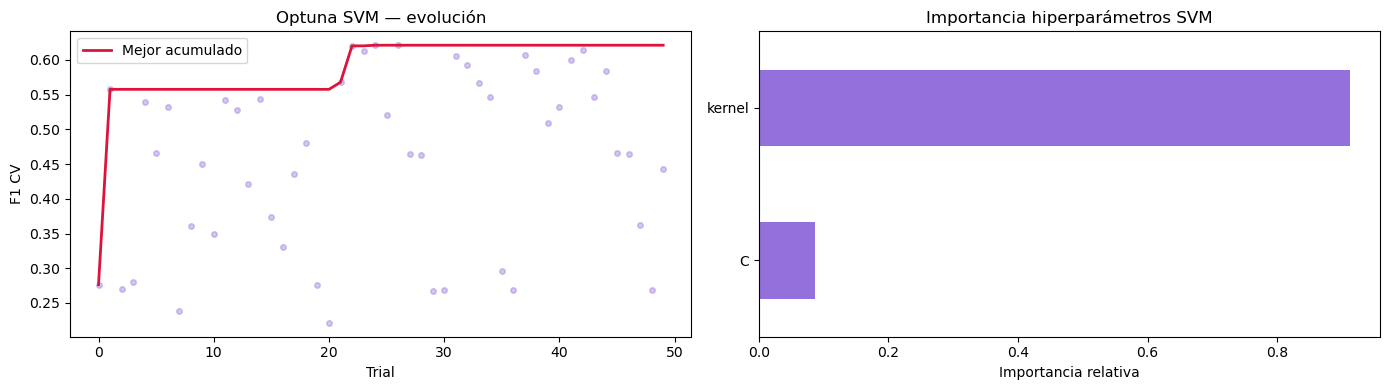

In [5]:
# Historial + importancia
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study_svm.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'],
             'o', alpha=0.4, color='mediumpurple', ms=4)
axes[0].plot(trials_df['number'], trials_df['value'].cummax(),
             color='crimson', lw=2, label='Mejor acumulado')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F1 CV')
axes[0].set_title('Optuna SVM — evolución')
axes[0].legend()

imp = optuna.importance.get_param_importances(study_svm)
pd.Series(imp).sort_values().plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Importancia hiperparámetros SVM')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()


## 3. SVM afinado — evaluación en test


In [6]:
# Reconstruir Pipeline con los mejores parámetros
# (se entrena siempre: el baseline solo se usa para la comparativa)
best = study_svm.best_params
svc_params = dict(best)
svc_params['class_weight'] = 'balanced'
svc_params['probability']  = True
svc_params['random_state'] = 42

print('Entrenando SVM afinado...')
svm_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',   SVC(**svc_params, verbose=False)),
], verbose=True)
svm_tuned.fit(X_train, y_train)
print('SVM afinado listo.')

y_prob_svm = svm_tuned.predict_proba(X_test)[:, 1]
res_svm = eval_threshold(y_test, y_prob_svm)
thr_svm = res_svm['Umbral']

print(f'=== SVM afinado — umbral {thr_svm:.4f} ===')
print(classification_report(y_test, (y_prob_svm >= thr_svm).astype(int),
                             target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.4f}')

if res_svm_base is not None:
    print('\n--- SVM baseline vs SVM afinado ---')
    print(pd.DataFrame({'SVM baseline': res_svm_base,
                         'SVM afinado':  res_svm}).T.round(4).to_string())


Entrenando SVM afinado...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   0.7s
SVM afinado listo.
=== SVM afinado — umbral 0.0601 ===
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96      1932
       Fallo       0.29      0.88      0.44        68

    accuracy                           0.92      2000
   macro avg       0.64      0.90      0.70      2000
weighted avg       0.97      0.92      0.94      2000

ROC-AUC: 0.9532

--- SVM baseline vs SVM afinado ---
              Precision  Recall      F1  ROC-AUC  Umbral
SVM baseline     0.3471  0.8676  0.4958   0.9702  0.1008
SVM afinado      0.2927  0.8824  0.4396   0.9532  0.0601


## 4. Guardar

Este notebook guarda **solo** `svm_tuned`. Si aporta al ensemble se decide en `05_01_4_Stacking_AI4I` (sección v3).


In [7]:
import pickle as _pickle
_pkl = '../../models/models.pkl'
with open(_pkl, 'rb') as _f:
    _m = _pickle.load(_f)
_m['svm_tuned'] = svm_tuned
with open(_pkl, 'wb') as _f:
    _pickle.dump(_m, _f)
print('Guardado: svm_tuned | Total keys en pkl:', len(_m))


Guardado: svm_tuned | Total keys en pkl: 18


## 5. Conclusiones

- `svm_tuned` queda disponible en `models.pkl`.
- Su papel en el ensemble (stacking v3) se evalúa en **`05_01_4_Stacking_AI4I`** —
  históricamente el SVM **no mejoró** el stacking LGBM+RF y se descartó.
